# Imports

In [1]:
!pip install torch

In [2]:
import torch
z = torch.cuda.current_device()
z

0

In [3]:
import sys
print(sys.version)

3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]


In [4]:
!pip install elfen

In [5]:
!pip install git+https://github.com/mmmaurer/elfen.git

  Cloning https://github.com/mmmaurer/elfen.git to /tmp/pip-req-build-ndiycv0y
  Running command git clone --filter=blob:none --quiet https://github.com/mmmaurer/elfen.git /tmp/pip-req-build-ndiycv0y
  Resolved https://github.com/mmmaurer/elfen.git to commit 48747f537bf24428eaee11b2a52ae1c0de7b5bad
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for elfen: filename=elfen-1.2.4-py3-none-any.whl size=57641 sha256=716f91c23c330aee669dcbc856ec9528c58eb55a00cbadd3dd39c0cd2792b69d
  Stored in directory: /tmp/pip-ephem-wheel-cache-rmw7a0xz/wheels/73/12/7e/437571a4d9119afc5b890cf4102dbe1bfb481a83ace1b6e762
Successfully built elfen
  Attempting uninstall: elfen
    Found existing installation: elfen 1.2.3
    Uninstalling elfen-1.2.3:
      Successfully uninstalled elfen-1.2.3


In [6]:
!spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 28.2 MB/s eta 0:00:00m eta 0:00:010:01:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [7]:
!python -m wn download omw:1.4

Cached file found: /home/shekhar/.wn_data/downloads/16c278c2e49cbeed749469012a4c6cfa078b2db4
Skipping omw-pl:1.4 (plWordNet); already addedl.xml
Skipping omw-en:1.4 (OMW English Wordnet based on WordNet 3.0); already added
Skipping omw-eu:1.4 (Multilingual Central Repository (Basque)); already added
Skipping omw-id:1.4 (Wordnet Bahasa (Indonesian)); already added
Skipping omw-hr:1.4 (Croatian Wordnet); already added
Skipping omw-nn:1.4 (Norwegian Wordnet (Nynorsk)); already added
Skipping omw-lt:1.4 (Lithuanian  WordNet); already added
Skipping omw-nb:1.4 (Norwegian Wordnet (Bokmål)); already added
Skipping omw-ro:1.4 (Romanian Wordnet); already added
Skipping omw-iwn:1.4 (ItalWordNet); already added.xml
Skipping omw-pt:1.4 (OpenWN-PT); already addedt.xml
Skipping omw-fr:1.4 (WOLF (Wordnet Libre du Français)); already added
Skipping omw-he:1.4 (Hebrew Wordnet); already added
Skipping omw-arb:1.4 (Arabic WordNet (AWN v2)); already added
Skipping omw-sq:1.4 (Albanet); already added-sq.xm

In [8]:
import os

os.environ["POLARS_MAX_THREADS"] = "8"

In [9]:
!pip install pandas

In [10]:
import os
print(os.listdir("/home"))


['karthik', 'shekhar', 'ravi', 'lost+found']


# Reading the data 

In [3]:
import os
import json
import pandas as pd

data_path = "/home/shekhar/Desktop/code/persona/output2/Dissertation_All_Models"
rows = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".json"):
            filepath = os.path.join(root, file)

            # Load the JSON file
            with open(filepath, "r") as f:
                content = json.load(f)

            # Get dialog text
            dialog_text = " ".join([list(turn.values())[0] for turn in content["dialog"]])

            # Extract info from filename
            filename = file.replace(".json", "")
            parts = filename.split("_")

            topic = parts[0]
            temperature = parts[2]
            generation_number = int(parts[3])
            speaker1 = parts[4]
            speaker2 = parts[5]
            stance = parts[6]
            character_pair = f"{speaker1} and {speaker2}"

            # Determine culture
            culture = "UK" if "_UK" in root else "Iran"

            # Get model name (the folder just before culture folder)
            model = os.path.basename(os.path.dirname(root))

            # Append the row
            rows.append({
                "model": model,
                "culture": culture,
                "topic": topic,
                "temperature": temperature,
                "generation_number": generation_number,
                "character_pair": character_pair,
                "stance": stance,
                "text": dialog_text
            })

# Create DataFrame and save
df = pd.DataFrame(rows)
df.to_csv("all_data.csv", index=False)

# Preview
print(df.head(50))


                            model culture                 topic temperature  \
0   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.9   
1   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.7   
2   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
3   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.5   
4   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.7   
5   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
6   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
7   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.9   
8   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.9   
9   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
10  Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.1   
11  Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interraci

In [12]:
!pip install polars

In [13]:
import polars as pl
pl_df = pl.from_pandas(df)

In [14]:
#print(dir(extractor))


In [15]:
!pip install pyarrow

In [16]:
import pyarrow

In [17]:
!pip install spacy polars numpy pandas openpyxl fasttext pyarrow scikit-learn

# Extract all features

In [18]:
import polars as pl
from elfen.extractor import Extractor

# Load your dataset as a polars DataFrame
# example from csv
#df = pl.read_csv("path/to/your/dataset.csv")

# Initialize the Extractor with your DataFrame
# This will automatically load the spaCy model
# and preprocess the text column
# Assumes the text column is named "text"
extractor = Extractor(data = pl_df)

# Extract features
features = extractor.extract_features()

print(extractor.data.head())

Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...
Extracting tree_depth...
Extracting tree_branching...
Extracting n_noun_chunks...
Extracting n_per_dependency_type...
Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Ex

In [63]:
#print(extractor.data.head(10))

In [22]:
extractor.write_csv("all_output_features.csv")

In [32]:
import polars as pl

# Assuming 'output_features' is the DataFrame you're working with
output_features = extractor.data  # Example DataFrame from the extractor

# Get the number of columns
num_columns = output_features.width
print(f"The number of columns in 'output_features': {num_columns}")

# Save to CSV
output_features.write_csv("output_features.csv")


The number of columns in 'output_features': 1071


# comparsion between iran and uk and get the feature with noticable difference

###### To compare the results between Iran and UK cultures, we'll compute the average value for each feature (column) in your extracted features DataFrame. Then, we can calculate the difference between the average values for each culture (Iran vs. UK) and identify which columns show a noticeable difference.

Here's how to do it step by step:

Separate the Data by Culture: Filter the dataset into two subsets: one for Iran and one for UK.

Calculate the Average: For each subset (Iran and UK), calculate the average of each feature (column).

Compute the Difference: Compare the averages between Iran and UK for each column.

Identify Significant Differences: Determine which features have the largest differences.

In [23]:
import polars as pl
from elfen.extractor import Extractor

In [29]:
import polars as pl

# Polars DataFrame with the extracted features
df = extractor.data  # This is your already extracted features

# Step 1: Filter the dataset by 'culture' (Iran vs UK)
df_iran = df.filter(pl.col("culture") == "Iran")
df_uk = df.filter(pl.col("culture") == "UK")

# Step 2: Find numeric columns only (skip 'culture' and non-numeric)
numeric_cols = [
    col for col, dtype in zip(df.columns, df.dtypes) 
    if col != "culture" and dtype in (pl.Float32, pl.Float64, pl.Int32, pl.Int64)
]

# Step 3: Calculate the average for each column in the 'Iran' and 'UK' subsets
avg_iran = df_iran.select([
    pl.col(col).mean().alias(f"{col}_iran") for col in numeric_cols
])
avg_uk = df_uk.select([
    pl.col(col).mean().alias(f"{col}_uk") for col in numeric_cols
])

# Step 4: Combine the averages into a single DataFrame
comparison = pl.concat([avg_iran, avg_uk], how="horizontal")

# Step 5: Calculate the differences (Iran - UK)
differences = comparison.select([
    (pl.col(f"{col}_iran") - pl.col(f"{col}_uk")).alias(f"{col}_difference")
    for col in numeric_cols
])

# Step 6: Sort by absolute differences to find most noticeable features
sorted_differences = differences.select([
    pl.col(col).abs().alias(col)
    for col in differences.columns
]).transpose().with_columns([
    pl.col("column_0").alias("difference"),
    pl.Series("feature", differences.columns)
]).select(["feature", "difference"]).sort("difference", descending=True)

# Step 7: Preview the top 10 most different features
print(sorted_differences.head(50))


shape: (50, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ difference  │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ dugast_u_difference             ┆ NaN         │
│ hdd_difference                  ┆ NaN         │
│ herdan_v_difference             ┆ 5078.691127 │
│ yule_k_difference               ┆ 5078.687238 │
│ flesch_reading_ease_difference  ┆ 262.518371  │
│ …                               ┆ …           │
│ n_low_dominance_difference      ┆ 1.193857    │
│ n_controversial_iconicity_diff… ┆ 1.039171    │
│ n_high_aoa_difference           ┆ 1.013419    │
│ n_high_Auditory_sensorimotor_d… ┆ 0.960251    │
│ gunning_fog_difference          ┆ 0.953867    │
└─────────────────────────────────┴─────────────┘


In [28]:
sorted_differences.shape

(154, 2)

# one model one topic one temperture

In [41]:
import os
import json
import pandas as pd

# Define your data path
data_path = "/home/shekhar/Desktop/code/persona/output2/Dissertation_All_Models"
rows = []

# Walk through the directory and collect data
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".json"):
            filepath = os.path.join(root, file)

            # Load the JSON file
            with open(filepath, "r") as f:
                content = json.load(f)

            # Get dialog text
            dialog_text = " ".join([list(turn.values())[0] for turn in content["dialog"]])

            # Extract info from filename
            filename = file.replace(".json", "")
            parts = filename.split("_")

            topic = parts[0]
            temperature = parts[2]
            generation_number = int(parts[3])
            speaker1 = parts[4]
            speaker2 = parts[5]
            stance = parts[6]
            character_pair = f"{speaker1} and {speaker2}"

            # Determine culture
            culture = "UK" if "_UK" in root else "Iran"

            # Get model name (the folder just before culture folder)
            model = os.path.basename(os.path.dirname(root))

            # Append the row
            rows.append({
                "model": model,
                "culture": culture,
                "topic": topic,
                "temperature": temperature,
                "generation_number": generation_number,
                "character_pair": character_pair,
                "stance": stance,
                "text": dialog_text
            })

# Create DataFrame from all the collected rows
df = pd.DataFrame(rows)

# Preview
print(df.head(50))

                            model culture                 topic temperature  \
0   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.9   
1   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.7   
2   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
3   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.5   
4   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.7   
5   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
6   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
7   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.9   
8   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.9   
9   Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.3   
10  Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interracial Marriage         0.1   
11  Qwen_Qwen2.5-1.5B-Instruct_IR    Iran  Interraci

# llama 8 B EDUCATION 0.7

In [46]:
# ---- Step 1: Filter the DataFrame based on the specified conditions ----
filtered_df = df[
    (df["model"].str.contains("meta-llama_Llama-3.1-8B-Instruct")) &  # Filter for specific model
    (df["temperature"] == "0.7") &  # Filter for specific temperature (0.9 in this case)
    (df["topic"] == "Education") &  # Filter for the topic
    ((df["model"].str.endswith("_IR")) | (df["model"].str.endswith("_UK")))  # Filter for _IR or _UK
]

# ---- Step 2: Display the filtered data and print its shape ----
if filtered_df.empty:
    print("No data available for the specified model, temperature, and topic.")
else:
    print("Filtered Data:")
    print(filtered_df.head())  # Display the first few rows
    print("\nShape of filtered data:", filtered_df.shape)  # Print the shape of the filtered data


Filtered Data:
                                     model culture      topic temperature  \
28810  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
28811  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
28817  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
28818  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
28827  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   

       generation_number       character_pair        stance  \
28810                  1  Daughter and Father       Neutral   
28811                  5       Father and Son     Agreement   
28817                  5       Son and Father  Disagreement   
28818                  4       Mother and Son  Disagreement   
28827                  2  Mother and Daughter  Disagreement   

                                                    text  
28810  Ah, the education system, eh? Well, I suppose ...  
28811  Blimey, Dad. I rec

In [64]:
filtered_df.to_csv("filtered_data.csv", index=False)

In [47]:
# ---- Step 3: Feature extraction for the filtered data ----
import polars as pl
from elfen.extractor import Extractor

# Only proceed if there is data to extract features from
if not filtered_df.empty:
    # Convert the filtered Pandas DataFrame to a Polars DataFrame
    pl_df = pl.from_pandas(filtered_df)

    # Initialize the Extractor with the Polars DataFrame
    extractor = Extractor(data=pl_df)

    # Extract features
    features = extractor.extract_features()

    # Print the extracted features or preview the data
    print("\nExtracted Features:")
    print(extractor.data.head())

Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...
Extracting tree_depth...
Extracting tree_branching...
Extracting n_noun_chunks...
Extracting n_per_dependency_type...
Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Ex

In [65]:
extractor.write_csv("filtered_output_features.csv")

# llama 8b

In [4]:
# ---- Step 1: Filter the DataFrame based on the specified conditions ----
filtered_df_llama_8b = df[
    (df["model"].str.contains("meta-llama_Llama-3.1-8B-Instruct")) &  # Filter for specific model
    ((df["model"].str.endswith("_IR")) | (df["model"].str.endswith("_UK")))  # Filter for _IR or _UK
]

# ---- Step 2: Display the filtered data and print its shape ----
if filtered_df_llama_8b.empty:
    print("No data available for the specified model, temperature, and topic.")
else:
    print("Filtered Data:")
    print(filtered_df_llama_8b.head())  # Display the first few rows
    print("\nShape of filtered data:", filtered_df_llama_8b.shape)  # Print the shape of the filtered data


Filtered Data:
                                     model culture                 topic  \
24000  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
24001  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
24002  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
24003  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
24004  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   

      temperature  generation_number       character_pair        stance  \
24000         0.9                  4  Mother and Daughter       Neutral   
24001         0.7                  4  Father and Daughter  Disagreement   
24002         0.3                  1       Father and Son  Disagreement   
24003         0.5                  5  Father and Daughter  Disagreement   
24004         0.7                  3       Son and Mother  Disagreement   

                                                    text  
24000  Blimey, Mum

In [5]:
# ---- Step 3: Feature extraction for the filtered data ----
import polars as pl
from elfen.extractor import Extractor

# Only proceed if there is data to extract features from
if not filtered_df_llama_8b.empty:
    # Convert the filtered Pandas DataFrame to a Polars DataFrame
    pl_df = pl.from_pandas(filtered_df_llama_8b)

    # Initialize the Extractor with the Polars DataFrame
    extractor = Extractor(data=pl_df)

    # Extract features
    features_llama_8b = extractor.extract_features()

    # Print the extracted features or preview the data
    print("\nExtracted Features:")
    print(extractor.data.head())

Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...
Extracting tree_depth...
Extracting tree_branching...
Extracting n_noun_chunks...
Extracting n_per_dependency_type...
Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Ex

In [7]:
extractor.write_csv("filtered_output_features_llama_8b.csv")

In [57]:
df.keys()

Index(['model', 'culture', 'topic', 'temperature', 'generation_number',
       'character_pair', 'stance', 'text'],
      dtype='object')

In [8]:
# Convert back to Pandas for scikit-learn
feature_df_llama_8b = extractor.data.to_pandas()

print("\nExtracted Features:")
print(feature_df_llama_8b.head())
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
from sklearn.neural_network import MLPRegressor

# ---- Load ELFeN features ----
df1 = feature_df_llama_8b
df1['culture']

# Replace 'UK' with 1 and 'Iran' with 0 in the 'culture' column
df1['culture'] = df1['culture'].replace({'UK': 1, 'Iran': 0})

# Verify the changes
print(df1['culture'].head())

# keep only numeric feature columns
df1= df1.select_dtypes(include=["float64", "int64", "uint16", "uint32", "float32"])
df1.shape

# ---- Separate features and label ----
feat_cols = [c for c in df1.columns if c!="culture"]
lab_cols = [c for c in df1.columns if c=="culture"]

data = df1[feat_cols]
labels = df1[lab_cols]

print(data.head())
print(data.shape)
print()
print(labels.head())
print(labels.shape)

# ---- Scale features ----
scaler = StandardScaler()
data[data.columns] = scaler.fit_transform(data[data.columns])

# Add constant for statsmodels
data = sm.add_constant(data)
print(data.head())

# ---- Statistical approach ----
print("Statistical approach: ")
model = sm.OLS(labels["culture"], data)
res = model.fit()
print(res.summary())




Extracted Features:
                                 model culture                 topic  \
0  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
1  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
2  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
3  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   
4  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Interracial Marriage   

  temperature  generation_number       character_pair        stance  \
0         0.9                  4  Mother and Daughter       Neutral   
1         0.7                  4  Father and Daughter  Disagreement   
2         0.3                  1       Father and Son  Disagreement   
3         0.5                  5  Father and Daughter  Disagreement   
4         0.7                  3       Son and Mother  Disagreement   

                                                text  raw_sequence_length  \
0  Blimey, Mum. It's not something I'd rea

/tmp/ipykernel_2770149/4224283483.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['culture'] = df1['culture'].replace({'UK': 1, 'Iran': 0})


0    1
1    1
2    1
3    1
4    1
Name: culture, dtype: int64
   generation_number  raw_sequence_length  n_tokens  n_sentences  \
0                  4                 1841       455           51   
1                  4                 1743       434           43   
2                  1                 1575       416           50   
3                  5                 1326       394           44   
4                  3                 1774       449           48   

   tokens_per_sentence  n_characters  avg_word_length  n_types  n_long_words  \
0             8.921569          1520         3.340659      170            80   
1            10.093023          1436         3.308756      158            63   
2             8.320000          1288         3.096154      170            52   
3             8.954545          1081         2.743655      114            29   
4             9.354167          1452         3.233853      158            60   

   n_lemmas  ...  n_percent  n_work_of_art  n_q

/tmp/ipykernel_2770149/4224283483.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data.columns] = scaler.fit_transform(data[data.columns])


   const  generation_number  raw_sequence_length  n_tokens  n_sentences  \
0    1.0           0.707107             1.066576  0.594487     0.717727   
1    1.0           0.707107             0.471355  0.018259    -0.335479   
2    1.0          -1.414214            -0.549023 -0.475651     0.586076   
3    1.0           1.414214            -2.061369 -1.079318    -0.203828   
4    1.0           0.000000             0.659639  0.429850     0.322775   

   tokens_per_sentence  n_characters  avg_word_length   n_types  n_long_words  \
0            -0.519749      1.163518         1.054249  1.164235      1.551490   
1             0.238691      0.547958         0.884770  0.673592      0.192935   
2            -0.909226     -0.536600        -0.244625  1.164235     -0.686130   
3            -0.498399     -2.053516        -2.117187 -1.125433     -2.524176   
4            -0.239670      0.665207         0.486868  0.673592     -0.046810   

   ...  n_percent  n_work_of_art  n_quantity    n_norp     n_l

In [16]:
# Save summary
with open("Output_ELFeN_Stats.txt", "w") as text_file:
    text_file.write(str(res.summary()))
    
# ---- Machine learning approach ----
print("Machine learning approach:")
X_train, X_test, y_train, y_test = train_test_split(
    data, labels["culture"], test_size=0.20, random_state=42, shuffle=True
)

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Pearson correlation on test set:", pearsonr(list(preds), y_test))
print("Spearman correlation on test set:", spearmanr(list(preds), y_test))

weights = pd.DataFrame()
weights["feature"] = data.columns
weights["weight"] = model.coef_
print(weights)
print()
print()


# ---- Non-linear model ----
print("Machine learning with non-linear models (might take a little while):")
model = MLPRegressor(max_iter=10000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Pearson correlation on test set:", pearsonr(list(preds), y_test))
print("Spearman correlation on test set:", spearmanr(list(preds), y_test))


Machine learning approach:
Pearson correlation on test set: PearsonRResult(statistic=np.float64(0.9239811426683676), pvalue=np.float64(0.0))
Spearman correlation on test set: SignificanceResult(statistic=np.float64(0.8646284718052711), pvalue=np.float64(0.0))
                  feature    weight
0                   const  0.499517
1       generation_number  0.000460
2     raw_sequence_length -1.032310
3                n_tokens -0.164537
4             n_sentences  0.098212
...                   ...       ...
1060              n_event -0.002181
1061            n_ordinal -0.002567
1062                n_fac -0.002448
1063                n_law  0.001072
1064           n_language  0.000757

[1065 rows x 2 columns]


Machine learning with non-linear models (might take a little while):
Pearson correlation on test set: PearsonRResult(statistic=np.float64(0.9240026842076439), pvalue=np.float64(0.0))
Spearman correlation on test set: SignificanceResult(statistic=np.float64(0.8635779430676859), pva

In [22]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=900)  # Try with different alpha values
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Pearson correlation on test set:", pearsonr(list(preds), y_test))
print("Spearman correlation on test set:", spearmanr(list(preds), y_test))



Pearson correlation on test set: PearsonRResult(statistic=np.float64(0.9207889103466607), pvalue=np.float64(0.0))
Spearman correlation on test set: SignificanceResult(statistic=np.float64(0.8644936960680321), pvalue=np.float64(0.0))


In [34]:
import pandas as pd
import re

# Path to your .txt file
file_path = "/home/shekhar/Desktop/code/persona/Output_ELFeN_Stats.txt"  # Replace with your actual file path

# Read the .txt file line by line
with open(file_path, 'r') as file:
    lines = file.readlines()

# Step 1: Extract the lines where the regression results are
data_lines = []
start_reading = False

# Find the section where the results start (can be adjusted as needed)
for line in lines:
    if line.strip().startswith("const"):  # Look for the header or first result row
        start_reading = True
    if start_reading:
        data_lines.append(line.strip())

# Step 2: Parse the data from the lines (split by spaces or tabs)
parsed_data = []

for line in data_lines:
    # Split each line by whitespace and extract the data
    parts = re.split(r'\s+', line)  # This handles spaces and tabs
    if len(parts) == 7:  # Check if the line contains 7 columns (feature, coef, std_err, t, P>|t|, CI_025, CI_975)
        parsed_data.append(parts)

# Step 3: Convert the parsed data into a pandas DataFrame
columns = ['Feature', 'Coefficient', 'Std_Err', 't_Statistic', 'P_>|t|', 'CI_025', 'CI_975']
df = pd.DataFrame(parsed_data, columns=columns)

# Convert the numerical columns to the correct data types (coef, std_err, t_stat, etc.)
df['Coefficient'] = pd.to_numeric(df['Coefficient'], errors='coerce')
df['P_>|t|'] = pd.to_numeric(df['P_>|t|'], errors='coerce')

# Step 4: Filter significant features based on P-value <= 0.05
significant_neg = df.loc[(df['P_>|t|'] <= 0.05) & (df['Coefficient'] < 0)]['Feature'].tolist()
significant_pos = df.loc[(df['P_>|t|'] <= 0.05) & (df['Coefficient'] > 0)]['Feature'].tolist()

# Step 5: Print the results
print("Significant negative features (more Iran-like):", significant_neg)
print("Significant positive features (more UK-like):", significant_pos)

# Optional: Save the filtered results to a CSV
output_csv_path = "/home/shekhar/Desktop/code/persona/significant_features.csv"
df.to_csv(output_csv_path, index=False)
print(f"Filtered features saved to {output_csv_path}")


Significant negative features (more Iran-like): ['raw_sequence_length', 'n_PRON_PronType_Prs', 'n_PRON_Gender_Fem', 'n_PRON_Gender_Masc', 'n_PRON_Gender_Neut', 'n_PRON_Case_Acc', 'n_PRON_Deixis_Even', 'n_DET_Number_Plur', 'n_DET_Definite_Def', 'n_DET_Definite_Ind', 'n_PUNCT_PunctType_Brck', 'n_PUNCT_PunctType_Peri', 'n_PUNCT_PunctSide_Fin', 'n_dependency_meta', 'n_dependency_nummod', 'n_low_valence', 'n_high_valence', 'n_high_arousal', 'avg_dominance', 'n_high_intensity_surprise', 'herdan_c', 'dugast_u', 'n_global_token_hapax_legomena', 'n_global_lemma_hapax_dislegomena', 'sichel_s', 'hdd', 'n_propn', 'n_high_aoa', 'n_controversial_aoa', 'avg_prevalence', 'n_low_prevalence', 'n_high_prevalence', 'n_high_socialness', 'avg_Interoceptive_sensorimotor', 'avg_Hand_arm_sensorimotor', 'avg_Head_sensorimotor', 'n_low_Hand_arm_sensorimotor', 'n_high_Auditory_sensorimotor', 'n_high_Hand_arm_sensorimotor', 'n_high_Mouth_sensorimotor', 'avg_sd_Haptic_sensorimotor', 'avg_sd_Olfactory_sensorimotor',

In [36]:
# Format the negative and positive features with line breaks
significant_neg_str = "\n".join(significant_neg)  # Join each item with a new line
significant_pos_str = "\n".join(significant_pos)  # Join each item with a new line

# Step 5: Print the results with line breaks
print("Significant negative features (more Iran-like):\n")
print(significant_neg_str)  # Print the negative features with line breaks

print("\nSignificant positive features (more UK-like):\n")
print(significant_pos_str)  # Print the positive features with line breaks

# Optional: Save the filtered results to a CSV
output_csv_path = "/home/shekhar/Desktop/code/persona/significant_features.csv"
df.to_csv(output_csv_path, index=False)
print(f"\nFiltered features saved to {output_csv_path}")


Significant negative features (more Iran-like):

raw_sequence_length
n_PRON_PronType_Prs
n_PRON_Gender_Fem
n_PRON_Gender_Masc
n_PRON_Gender_Neut
n_PRON_Case_Acc
n_PRON_Deixis_Even
n_DET_Number_Plur
n_DET_Definite_Def
n_DET_Definite_Ind
n_PUNCT_PunctType_Brck
n_PUNCT_PunctType_Peri
n_PUNCT_PunctSide_Fin
n_dependency_meta
n_dependency_nummod
n_low_valence
n_high_valence
n_high_arousal
avg_dominance
n_high_intensity_surprise
herdan_c
dugast_u
n_global_token_hapax_legomena
n_global_lemma_hapax_dislegomena
sichel_s
hdd
n_propn
n_high_aoa
n_controversial_aoa
avg_prevalence
n_low_prevalence
n_high_prevalence
n_high_socialness
avg_Interoceptive_sensorimotor
avg_Hand_arm_sensorimotor
avg_Head_sensorimotor
n_low_Hand_arm_sensorimotor
n_high_Auditory_sensorimotor
n_high_Hand_arm_sensorimotor
n_high_Mouth_sensorimotor
avg_sd_Haptic_sensorimotor
avg_sd_Olfactory_sensorimotor
avg_sd_Torso_sensorimotor
n_controversial_Gustatory_sensorimotor
n_controversial_Interoceptive_sensorimotor
n_controversial_H

In [35]:
df

,Feature,Coefficient,Std_Err,t_Statistic,P_>|t|,CI_025,CI_975
0,const,0.5000,0.002,284.615,0.000,0.497,0.503
1,generation_number,0.0006,0.002,0.310,0.757,-0.003,0.004
2,raw_sequence_length,-0.9518,0.137,-6.923,0.000,-1.221,-0.682
3,n_tokens,-0.2450,0.149,-1.646,0.100,-0.537,0.047
4,n_sentences,0.0981,0.024,4.107,0.000,0.051,0.145
...,...,...,...,...,...,...,...
1060,n_event,-0.0019,0.002,-1.056,0.291,-0.005,0.002
1061,n_ordinal,-0.0017,0.002,-0.920,0.357,-0.005,0.002
1062,n_fac,-0.0038,0.002,-1.988,0.047,-0.008,-5.41e-05
1063,n_law,0.0016,0.002,0.906,0.365,-0.002,0.005


# classifing the uk and iran dialogs

In [48]:
    # Convert back to Pandas for scikit-learn
    feature_df = extractor.data.to_pandas()

    print("\nExtracted Features:")
    print(feature_df.head())


Extracted Features:
                                 model culture      topic temperature  \
0  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
1  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
2  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
3  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   
4  meta-llama_Llama-3.1-8B-Instruct_UK      UK  Education         0.7   

   generation_number       character_pair        stance  \
0                  1  Daughter and Father       Neutral   
1                  5       Father and Son     Agreement   
2                  5       Son and Father  Disagreement   
3                  4       Mother and Son  Disagreement   
4                  2  Mother and Daughter  Disagreement   

                                                text  \
0  Ah, the education system, eh? Well, I suppose ...   
1  Blimey, Dad. I reckon it's all a bit of a mine...   
2  Ah, education,

In [6]:
feature_df.shape

NameError: name 'feature_df' is not defined

In [67]:
# Get the data types of each column
column_types = feature_df.dtypes

# Print the type of each column
print("\nColumn Types:")
print(column_types)

# Count how many columns of each type exist
type_counts = column_types.value_counts()

# Print the counts of each type
print("\nCount of each data type:")
print(type_counts)



Column Types:
model                object
culture              object
topic                object
temperature          object
generation_number     int64
                      ...  
n_event              uint16
n_ordinal            uint16
n_fac                uint16
n_law                uint16
n_language           uint16
Length: 1080, dtype: object

Count of each data type:
uint16     894
float64    100
int64       48
object      16
uint32      16
float32      6
Name: count, dtype: int64


In [68]:
# Find columns with 'object' data type
object_columns = feature_df.select_dtypes(include=['object'])

# Display the names of these columns
print("\nColumns with 'object' data type:")
print(object_columns.columns)



Columns with 'object' data type:
Index(['model', 'culture', 'topic', 'temperature', 'character_pair', 'stance',
       'text', 'nlp', 'lemmas', 'tokens', 'token_freqs', 'synsets',
       'synsets_noun', 'synsets_verb', 'synsets_adj', 'synsets_adv'],
      dtype='object')


In [61]:
row = feature_df.iloc[0]

model
culture
topic
temperature
generation_number
character_pair
stance
text
nlp
raw_sequence_length
n_tokens
n_sentences
tokens_per_sentence
n_characters
avg_word_length
n_types
n_long_words
n_lemmas
n_VERB_VerbForm_Conf
n_VERB_VerbForm_Fin
n_VERB_VerbForm_Gdv
n_VERB_VerbForm_Ger
n_VERB_VerbForm_Inf
n_VERB_VerbForm_Part
n_VERB_VerbForm_Sup
n_VERB_VerbForm_Vnoun
n_VERB_Mood_Adm
n_VERB_Mood_Cnd
n_VERB_Mood_Des
n_VERB_Mood_Imp
n_VERB_Mood_Ind
n_VERB_Mood_Irr
n_VERB_Mood_Jus
n_VERB_Mood_Nec
n_VERB_Mood_Opt
n_VERB_Mood_Pot
n_VERB_Mood_Prp
n_VERB_Mood_Qot
n_VERB_Mood_Sub
n_VERB_Tense_Fut
n_VERB_Tense_Imp
n_VERB_Tense_Past
n_VERB_Tense_Pres
n_VERB_Tense_Pqp
n_VERB_Aspect_Hab
n_VERB_Aspect_Imp
n_VERB_Aspect_Iter
n_VERB_Aspect_Perf
n_VERB_Aspect_Prog
n_VERB_Aspect_Prosp
n_VERB_Voice_Act
n_VERB_Voice_Antip
n_VERB_Voice_Bfoc
n_VERB_Voice_Cau
n_VERB_Voice_Dir
n_VERB_Voice_Inv
n_VERB_Voice_Lfoc
n_VERB_Voice_Mid
n_VERB_Voice_Pass
n_VERB_Voice_Rcp
n_VERB_Evident_Fh
n_VERB_Evident_Nfh
n_VERB_Polarity

In [62]:
row = feature_df.iloc[0]
for col, val in row.items():
    print(f"{col}:{val}")

model:meta-llama_Llama-3.1-8B-Instruct_UK
culture:UK
topic:Education
temperature:0.7
generation_number:1
character_pair:Daughter and Father
stance:Neutral
text:Ah, the education system, eh? Well, I suppose it's a bit of a mixed bag, innit? Oh, really? What do you mean? Father Well, on the one hand, the schools are generally quite good, I think. Yes, yes, the teachers are usually decent chaps, and the facilities are usually all right. Daughter But what about the curriculum? [CHUCKLES]:  Oh, I know what you mean. It's all so...standardised, isn't it? Father Exactly! I mean, what's the point of learning all this stuff, if you're not going to use it in real life? Well, I suppose that's true. But don't you think that's what university is for? Ah, university! [LAUGHS]:  Well, I suppose that's a different story altogether. [LAUGHS]:  Oh, I know what you mean. Anyway, it's all a bit of a debate, isn't it? Yes, it certainly is, Father. Father [CHUCKLES]:  Well, I suppose that's the beauty of it

# linear regression

In [73]:
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 22.5 MB/s eta 0:00:00m eta 0:00:0136m0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 KB 21.6 MB/s eta 0:00:00


In [79]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
from sklearn.neural_network import MLPRegressor

# ---- Load ELFeN features ----
df1 = feature_df
df1['culture']

0        UK
1        UK
2        UK
3        UK
4        UK
       ... 
235    Iran
236    Iran
237    Iran
238    Iran
239    Iran
Name: culture, Length: 240, dtype: object

In [80]:
# Replace 'UK' with 1 and 'Iran' with 0 in the 'culture' column
df1['culture'] = df1['culture'].replace({'UK': 1, 'Iran': 0})

# Verify the changes
print(df1['culture'].head())


0    1
1    1
2    1
3    1
4    1
Name: culture, dtype: int64


/tmp/ipykernel_569728/1332392472.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['culture'] = df1['culture'].replace({'UK': 1, 'Iran': 0})


In [81]:
# keep only numeric feature columns
df1= df1.select_dtypes(include=["float64", "int64", "uint16", "uint32", "float32"])
df1.shape

(240, 1065)

In [87]:
# ---- Separate features and label ----
feat_cols = [c for c in df1.columns if c!="culture"]
lab_cols = [c for c in df1.columns if c=="culture"]

data = df1[feat_cols]
labels = df1[lab_cols]

print(data.head())
print(data.shape)
print()
print(labels.head())
print(labels.shape)



   generation_number  raw_sequence_length  n_tokens  n_sentences  \
0                  1                 1439       396           33   
1                  5                 1530       424           50   
2                  5                 1969       484           62   
3                  4                 1528       412           43   
4                  2                 1756       442           48   

   tokens_per_sentence  n_characters  avg_word_length  n_types  n_long_words  \
0            12.000000          1189         3.002525      124            63   
1             8.480000          1247         2.941038      154            64   
2             7.806452          1623         3.353306      175            79   
3             9.581395          1241         3.012136      159            48   
4             9.208333          1455         3.291855      176            66   

   n_lemmas  ...  n_percent  n_work_of_art  n_quantity  n_norp  n_loc  \
0       112  ...          0          

In [91]:
print(data.columns)

Index(['generation_number', 'raw_sequence_length', 'n_tokens', 'n_sentences',
       'tokens_per_sentence', 'n_characters', 'avg_word_length', 'n_types',
       'n_long_words', 'n_lemmas',
       ...
       'n_percent', 'n_work_of_art', 'n_quantity', 'n_norp', 'n_loc',
       'n_event', 'n_ordinal', 'n_fac', 'n_law', 'n_language'],
      dtype='object', length=1064)


In [93]:
# ---- Scale features ----
scaler = StandardScaler()
data[data.columns] = scaler.fit_transform(data[data.columns])

# Add constant for statsmodels
data = sm.add_constant(data)
print(data.head())

/tmp/ipykernel_569728/2573115855.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data.columns] = scaler.fit_transform(data[data.columns])


   const  generation_number  raw_sequence_length  n_tokens  n_sentences  \
0    1.0          -1.414214            -1.637000 -0.941225    -1.544453   
1    1.0           1.414214            -1.062835 -0.178438     0.788523   
2    1.0           1.414214             1.707035  1.456106     2.435329   
3    1.0           0.707107            -1.075454 -0.505347    -0.172114   
4    1.0          -0.707107             0.363112  0.311926     0.514055   

   tokens_per_sentence  n_characters  avg_word_length   n_types  n_long_words  \
0             1.204077     -1.535775        -1.253337 -1.127713     -0.241329   
1            -0.874655     -1.095355        -1.585793  0.228708     -0.163793   
2            -1.272418      1.759781         0.643294  1.178202      0.999237   
3            -0.224227     -1.140915        -1.201373  0.454778     -1.404359   
4            -0.444538      0.484082         0.311037  1.223416     -0.008723   

   ...  n_percent  n_work_of_art  n_quantity    n_norp     n_l

In [94]:
# ---- Statistical approach ----
print("Statistical approach: ")
model = sm.OLS(labels["culture"], data)
res = model.fit()
print(res.summary())

Statistical approach: 


/home/shekhar/Desktop/code/persona/myenv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/shekhar/Desktop/code/persona/myenv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/shekhar/Desktop/code/persona/myenv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/home/shekhar/Desktop/code/persona/myenv/lib/python3.10/site-packages/statsmodels/base/model.py:1527: RuntimeWarning: invalid value encountered in multiply
  cov_p = self.normalized_cov_params * scale


                            OLS Regression Results                            
Dep. Variable:                culture   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 02 Oct 2025   Prob (F-statistic):                nan
Time:                        15:19:10   Log-Likelihood:                 7733.2
No. Observations:                 240   AIC:                        -1.499e+04
Df Residuals:                       0   BIC:                        -1.415e+04
Df Model:                         239                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [9]:
# Save summary
with open("Output_ELFeN_Stats.txt", "w") as text_file:
    text_file.write(str(res.summary()))


In [10]:
# ---- Machine learning approach ----
print("Machine learning approach:")
X_train, X_test, y_train, y_test = train_test_split(
    data, labels["culture"], test_size=0.20, random_state=42, shuffle=True
)

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Pearson correlation on test set:", pearsonr(list(preds), y_test))
print("Spearman correlation on test set:", spearmanr(list(preds), y_test))


Machine learning approach:
Pearson correlation on test set: PearsonRResult(statistic=np.float64(0.9239811426683676), pvalue=np.float64(0.0))
Spearman correlation on test set: SignificanceResult(statistic=np.float64(0.8646284718052711), pvalue=np.float64(0.0))


In [11]:
weights = pd.DataFrame()
weights["feature"] = data.columns
weights["weight"] = model.coef_
print(weights)
print()
print()


                  feature    weight
0                   const  0.499517
1       generation_number  0.000460
2     raw_sequence_length -1.032310
3                n_tokens -0.164537
4             n_sentences  0.098212
...                   ...       ...
1060              n_event -0.002181
1061            n_ordinal -0.002567
1062                n_fac -0.002448
1063                n_law  0.001072
1064           n_language  0.000757

[1065 rows x 2 columns]




In [12]:
# ---- Non-linear model ----
print("Machine learning with non-linear models (might take a little while):")
model = MLPRegressor(max_iter=10000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Pearson correlation on test set:", pearsonr(list(preds), y_test))
print("Spearman correlation on test set:", spearmanr(list(preds), y_test))


Machine learning with non-linear models (might take a little while):
Pearson correlation on test set: PearsonRResult(statistic=np.float64(0.9256054320378464), pvalue=np.float64(0.0))
Spearman correlation on test set: SignificanceResult(statistic=np.float64(0.8629762656692982), pvalue=np.float64(0.0))


In [13]:
# ---- Extract significant features 
usr_el_features = pd.DataFrame({
    "feature": data.columns,
    "coef": model.coef_,
    "P>|t|": res.pvalues
})

significant_neg = usr_el_features.loc[(usr_el_features['P>|t|'] <= 0.05) & (usr_el_features.coef < 0)].feature.tolist()
significant_pos = usr_el_features.loc[(usr_el_features['P>|t|'] <= 0.05) & (usr_el_features.coef > 0)].feature.tolist()

print("Significant negative features (more Iran-like):", significant_neg)
print("Significant positive features (more UK-like):", significant_pos)



AttributeError: 'MLPRegressor' object has no attribute 'coef_'

In [54]:
!pip install seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 3.7 MB/s eta 0:00:006.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 25.0 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 50.7 MB/s eta 0:00:00m eta 0:00:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 KB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 28.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 72.4 MB/s eta 0:00:002 MB/s eta 0:00:01


In [ ]:
uint16     894
float64    100
int64       48
object      16
uint32      16
float32      6

In [69]:
   ## ---- Step 4: Classification Setup ----
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# X = all extracted features (drop metadata columns like model/topic/text)
# keep only numeric feature columns
X = feature_df.select_dtypes(include=["float64", "int64", "uint16", "uint32", "float32"])
X.shape

(240, 1064)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.96      1.00      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

Accuracy: 0.9791666666666666


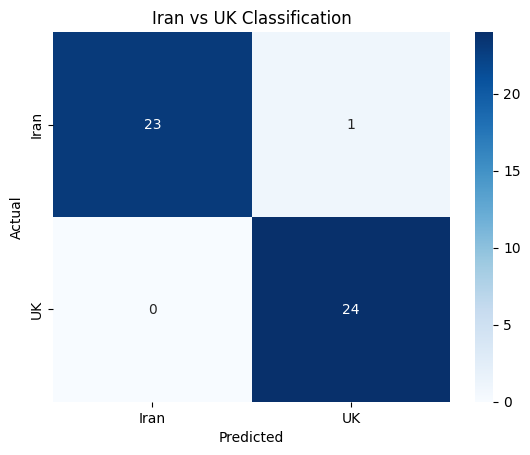


Top Features Driving Classification:
                                    feature  coefficient
1050                               n_person     0.189016
932                                  n_part     0.180006
270                         n_PRON_Case_Nom     0.155980
837                        n_dependency_neg     0.150772
2                                  n_tokens     0.141593
969             n_low_Auditory_sensorimotor     0.134434
928                                   n_det     0.130872
834                       n_dependency_intj     0.119013
1037                    n_high_synsets_noun     0.118808
941                      n_low_concreteness     0.115400
1002  n_controversial_Auditory_sensorimotor     0.100186
925                                   n_aux     0.097394
1036                         n_high_synsets     0.095716
1015                       n_high_iconicity     0.095010
831                        n_dependency_det     0.093258

Bottom Features (more Iran-like):
               

In [70]:
 
    # y = labels (UK = 1, Iran = 0)
    y = feature_df["culture"].apply(lambda x: 1 if "UK" in x else 0)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ---- Step 5: Train Classifier ----
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)

    # ---- Step 6: Evaluation ----
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Iran","UK"], yticklabels=["Iran","UK"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Iran vs UK Classification")
    plt.show()

    # ---- Step 7: Feature Importance ----
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "coefficient": clf.coef_[0]
    }).sort_values(by="coefficient", ascending=False)

    print("\nTop Features Driving Classification:")
    print(feature_importance.head(15))
    print("\nBottom Features (more Iran-like):")
    print(feature_importance.tail(15))


In [71]:
# Extract a single feature
# In this case, we are extracting the "average_word_length" feature
extractor.extract("avg_word_length")

print(extractor.data[['avg_word_length']].head())

shape: (5, 1)
┌─────────────────┐
│ avg_word_length │
│ ---             │
│ f64             │
╞═════════════════╡
│ 3.002525        │
│ 2.941038        │
│ 3.353306        │
│ 3.012136        │
│ 3.291855        │
└─────────────────┘


In [ ]:
print(extractor.data.select([
    "lemma_token_ratio",
    "ttr",
    "cttr",
    "rttr",
    "herdan_c",
    "summer_index",
    "dugast_u",
    "maas_index",
    "n_hapax_legomena",
    "n_global_lemma_hapax_legomena",
    "n_global_token_hapax_legomena",
    "lexical_density",
    "n_hapax_dislegomena",
    "n_global_lemma_hapax_dislegomena",
    "n_global_token_hapax_dislegomena",
    "hdd",
    "sichel_s",
    "global_sichel_s",
    "giroud_index",
    "mtld",
    "mattr",
    "msttr",
    "yule_k",
    "simpsons_d",
    "herdan_v"
]).head())


In [ ]:
print(extractor.data.tail(50))

# emotion features

In [ ]:
!pip install elfen

In [ ]:
import elfen


In [ ]:
import elfen.emotion

In [ ]:
import elfen
import polars as pl
import spacy
from elfen.emotion import load_vad_lexicon, get_avg_valence, get_avg_arousal, get_avg_dominance


# loading the VAD lexicon

In [ ]:
# Path to your VAD lexicon file (adjust the path based on where your files are stored)
vad_file_path = "/home/shekhar/Desktop/code/persona/NRC-VAD-Lexicon-ForVariousLanguages.txt"

# Define the schema for the VAD lexicon (it should match the structure of the lexicon)
VAD_LEXICON_SCHEMA = {
    "word": str,
    "valence": float,
    "arousal": float,
    "dominance": float
}

# Load the VAD lexicon into a Polars DataFrame
vad_lexicon = load_vad_lexicon(vad_file_path, schema=VAD_LEXICON_SCHEMA)


In [ ]:
# Load the spaCy NLP model"PREAPER THE DATA"
nlp = spacy.load("en_core_web_sm")

# Process the text using spaCy
doc = nlp(df)

# Convert the processed text into a Polars DataFrame
data = pl.DataFrame({
    "nlp": [doc]
})


In [ ]:
intensity_path = "/home/shekhar/Desktop/code/persona/lexicons/intensity_lexicon.csv"
intensity_schema = {
    "word": "word_column_name",
    "emotion": "emotion_column_name",
    "intensity": "intensity_column_name"
}

sentiment_path = "/home/shekhar/Desktop/code/persona/lexicons/sentiment_nrc.csv"
sentiment_schema = {
    "word": "word_column_name",
    "sentiment": "sentiment_column_name"
}

vad_path = "/home/shekhar/Desktop/code/persona/lexicons/vad_lexicon.csv"
vad_schema = {
    "word": "word_column_name",
    "valence": "valence_column_name",
    "arousal": "arousal_column_name",
    "dominance": "dominance_column_name"
}


In [ ]:
intensity_lex = elfen.emotion.load_intensity_lexicon(path=intensity_path, schema=intensity_schema)
sentiment_lex = elfen.emotion.load_sentiment_nrc_lexicon(path=sentiment_path, schema=sentiment_schema)
vad_lex = elfen.emotion.load_vad_lexicon(path=vad_path, schema=vad_schema)


In [ ]:
# Print the names of the columns in the Polars DataFrame
print(extractor.data.columns)


In [ ]:
pip install openpyxl polars


In [ ]:
import polars as pl
import pandas as pd

# Assuming 'extractor.data' is your Polars DataFrame
df = extractor.data  # Replace with your actual DataFrame

# Convert the Polars DataFrame to a Pandas DataFrame
df_pandas = df.to_pandas()

# Define the file path where you want to save the Excel file
excel_file_path = "/home/shekhar/Desktop/code/persona/persona.xlsx"  # Full path with the filename

# Write to Excel (using OpenPyXL as the engine)
df_pandas.to_excel(excel_file_path, engine='openpyxl', index=False)

# Print the path where the data has been saved
print(f"Data has been saved to: {excel_file_path}")


In [ ]:
print(extractor.data.dtypes)


### Save the Polars DataFrame to CSV

In [ ]:
# Extracting features using the `extract_features()` method
features = extractor.extract_features()

# Now concatenate the features with your existing data
result = pd.concat([df, features], axis=1)

# Display the first few rows of the resulting dataframe
print(result.head())

In [ ]:
get_data(result)

In [ ]:
# If features is a Polars DataFrame, convert it
features_pd = features.to_pandas()
# Concatenate
result = pd.concat([df, features_pd], axis=1)



In [ ]:
features = extractor.extract_features()
print("Returned type:", type(features))


### View more columns

In [ ]:
# Show ALL columns
pd.set_option('display.max_columns', None)

# Show ALL rows (careful with large dataframes)
#pd.set_option('display.max_rows', None)

# Now display
print(result.head())  # or result


In [ ]:
result.head()  #render a scrollable HTML table


In [ ]:
result.to_csv("extracted_features.csv", index=False)
# OR
result.to_excel("extracted_features.xlsx", index=False)


In [ ]:
print("Original df shape:", df.shape)
print("Extracted features shape:", features.shape)
print("Final result shape:", result.shape)


In [ ]:
print(type(features))


In [ ]:
features = extractor.transform()
result = pd.concat([data, feature], axis=1)
print(result.head())

In [ ]:
import os
import json
import pandas as pd
import polars as pl
from elfen import resources
from elfen.features import (
    get_sentiment_score, get_avg_valence, get_avg_arousal, get_avg_dominance,
    get_flesch_reading_ease, get_gunning_fog, get_lix, get_smog, get_ari,
    get_ttr, get_mtld, get_mattr, get_hdd, get_maas_index, get_yule_k,
    get_avg_concreteness, get_avg_iconicity, get_avg_sensorimotor, get_avg_socialness,
    get_tree_depth, get_tree_width, get_tree_branching, get_pos_variability,
    get_num_tokens, get_num_sentences, get_num_tokens_per_sentence, get_num_entities
)

In [ ]:
# Check how download_lexicon is implemented in elfen.resources
help(download_lexicon)


In [ ]:
from elfen.resources import download_lexicon
from elfen.semantic import load_hedges

# Step 1: Download the lexicon (if you haven't already)
lexicon_path = download_lexicon("hedges", path="/home/shekhar/Desktop/code/persona")

# Step 2: Load the lexicon using the downloaded file path
hedges = load_hedges(lexicon_path)

# Step 3: Print the loaded hedge words
print(hedges)


In [ ]:
# Get hedge lexicon path
hedge_lexicon_path = resources.get_resource("hedges")

print("Hedge lexicon path:", hedge_lexicon_path)


In [ ]:
import elfen.semantic
help(elfen.semantic.load_hedges)


In [ ]:
from elfen.semantic import load_hedges

hedges = load_hedges()
print(hedges)


In [ ]:
# Create folder to store the downloaded lexicon
lexicon_folder = "/home/shekhar/Desktop/code/persona/elfen_lexicons"
os.makedirs(lexicon_folder, exist_ok=True)

# Download hedge lexicon
hedge_lexicon_path = resources.download_lexicon("hedges", path=lexicon_folder)

print("Downloaded hedge lexicon to:", hedge_lexicon_path)